In [1]:
import networkx as nx 
import matplotlib.pyplot as plt

# Spectral Graph Theory: Finding Structure in Networks 
## Traffic Optimization Using Spectral Graph Theory

## Preparation
1. What to research:
    - eigenvectors(refresh knowledge)
    - clustering algorithms
    - community detection in social networks
    - neural brain networks, transportation system or recommendation systems
    - Laplacian matrix, Adjacency, edge and their connection
    - How to discover the hidden structure inside networks maybe even make some connection to nature/biology
    - add later a relation to a topic that interests you and is a guess-prove type of logic behind it #TO-DO
    - Fiedler value - to show how well connected the network is
    - https://networksciencebook.com/
    - https://math.mit.edu/~spielman/561/
    - https://networkx.org/documentation/stable/ - networkx documentation
2. What actually is Sprectral Graph Theory?
   - Spectral graph theory starts by associating matrices to graphs, notably,
     the adjacency matrix and the laplacian matrix (see: 'A BRIEF INTRODUCTION TO SPECTRAL GRAPH THEORY'- BOGDAN NICA) /
   - The main objective of spectral graph theory is to relate properties of graphs with the eigenvalues
     and eigenvectors (spectral properties) of associated matrices.(see: 
     'Lecture11: Introduction to Spectral Graph Theory - RajatMittal, IITKanpur)<-
3. Plan
    1. Make a random model(or use a model of the roads of a town/ part of a city like the center of Sofia)
      and with probality and statistics simulate :
        - a random traffic flow
        - congestion probability
        - route usage
    2. Analyze Traffik Bottlenecks
        - Whats a Traffik Bottleneck? - It is a localized disruption of vehicular traffic on a street, road, or highway
        - Whats the difference between a traffik jam and a bottleneck? Bottleneck is a result of a specific physical condition like :
            - design of the road
            - badly timed traffic lights
            - sharp curves
            - temporary situations, such as vehicular accidents.

## Research 

### Terms and Explanations
1. Undirected graph
    - Let's start from 0: A graph is a group of dots connected by lines. The dots could represent things(people, places, math equation results;
       we will refer to them as **nodes**). The lines between these dots are called **edges** (the connections).
    - An undirected graph is a type of graph where the edges have no specified direction assigned to the them.(geeksforgeeks)
    - If we care only if two nodes are connected or not, we call such a graph **unweighted**.
    - For the nodes with an edge between them, we say they are **adjacent** or neighbors of one another.
    - $G=(V,E)$ is a set of vertices $V$ and a set of connections $E \subseteq V \times V$ between these vertices 
    - Its edges are bidirectional
        - To represent that relationship that goes both ways we use sets {}. Example: $\{'Tom', 'Jerry'\}$ 
    - may contain loops(edges that connect a vertex to itself)
    - degree of each edge is the same as the number of edges connected to it
    - One of the ways to represent a graph is with an **edge-list** - it shows the node-pair relationships (see:
      datagy.io representing graphs in python)
2. Directed graph
   - We represent the edges as arrrows not lines and the edge-list as a tuple
     Example: $[('Joe', 'Black'), ('Black', 'Sabbath'), \dots]$
$$d = \text{the degree of the edges}$$

In [16]:
def graph_from_edges(edges:list, directed:bool=False) -> None:
        
    G = nx.DiGraph() if directed else nx.Graph()
    if all(len(edge) == 3 for edge in edges):
        G.add_weighted_edges_from(edges)
    elif all(len(edge) == 2 for edge in edges):
        G.add_edges_from(edges)
    else:
        raise ValueError("Edges must be (u, v) or (u, v, weight) tuples")
        
    G.add_weighted_edges_from(edges)
    
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw_networkx_nodes(
        G, pos, node_color='lightblue', node_size=800
    )
    nx.draw_networkx_edges(
        G, pos, edge_color='green', width=2
    )
    nx.draw_networkx_labels(
        G, pos, font_size=10, font_weight='bold'
    )
    
    plt.title(f"{'Directed' if directed else 'Undirected'} graph")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

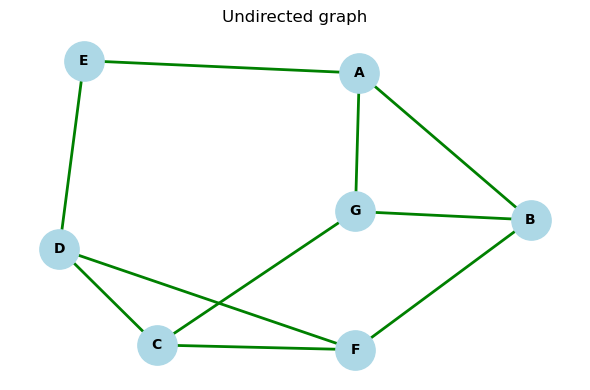

In [17]:
edges_list = [
        ('A', 'B', 4),#start_node -> end_node, weight(distance/strength of connection/time/capacity/etc. )
        ('C', 'D', 6),
        ('E', 'D', 4),
        ('A', 'E', 5),
        ('G', 'B', 7),
        ('F', 'D', 4),
        ('A', 'G', 5),
        ('C', 'G', 5),
        ('F', 'B', 5),
        ('C', 'F', 3)
]
graph_from_edges(edges_list)

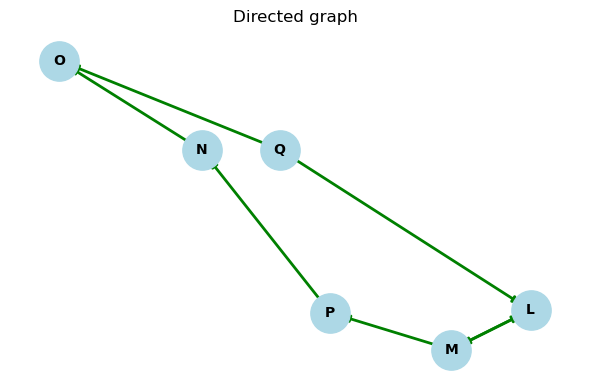

In [26]:
directed_edges = [
    ("P", "N", 3),
    ("Q", "O", 4),
    ("L", "M", 7),
    ("M", "P", 2),
    ("N", "O", 4),
    ("Q", "L", 3),
    ("M", "L", 2)
]
graph_from_edges(directed_edges, directed=True)

#### Legend (#TO-DO)
